In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


# Heart Disease Dataset Exploration

This notebook performs an initial exploration and quality assessment of the Heart Disease dataset before preprocessing and machine learning.

In [2]:
df = pd.read_csv("../data/raw/heart.csv")

df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [3]:
df.shape

(918, 12)

In [4]:
df.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='str')

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    str    
 2   ChestPainType   918 non-null    str    
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    str    
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    str    
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    str    
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), str(5)
memory usage: 86.2 KB


In [6]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Age,918.0,NaN,NaN,NaN,53.510893,9.432617,28.0,47.0,54.0,60.0,77.0
Sex,918,2,M,725,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ChestPainType,918,4,ASY,496,NaN,NaN,NaN,NaN,NaN,NaN,NaN
RestingBP,918.0,NaN,NaN,NaN,132.396514,18.514154,0.0,120.0,130.0,140.0,200.0
Cholesterol,918.0,NaN,NaN,NaN,198.799564,109.384145,0.0,173.25,223.0,267.0,603.0
FastingBS,918.0,NaN,NaN,NaN,0.233115,0.423046,0.0,0.0,0.0,0.0,1.0
RestingECG,918,3,Normal,552,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MaxHR,918.0,NaN,NaN,NaN,136.809368,25.460334,60.0,120.0,138.0,156.0,202.0
ExerciseAngina,918,2,N,547,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Oldpeak,918.0,NaN,NaN,NaN,0.887364,1.06657,-2.6,0.0,0.6,1.5,6.2


In [7]:
df.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df["HeartDisease"].value_counts()

HeartDisease
1    508
0    410
Name: count, dtype: int64

In [10]:
df["HeartDisease"].value_counts(normalize=True) * 100

HeartDisease
1    55.337691
0    44.662309
Name: proportion, dtype: float64

In [11]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,918.0,53.510893,9.432617,28.0,47.00,54.0,60.0,77.0
RestingBP,918.0,132.396514,18.514154,0.0,120.00,130.0,140.0,200.0
Cholesterol,918.0,198.799564,109.384145,0.0,173.25,223.0,267.0,603.0
FastingBS,918.0,0.233115,0.423046,0.0,0.00,0.0,0.0,1.0
MaxHR,918.0,136.809368,25.460334,60.0,120.00,138.0,156.0,202.0
Oldpeak,918.0,0.887364,1.066570,-2.6,0.00,0.6,1.5,6.2
HeartDisease,918.0,0.553377,0.497414,0.0,0.00,1.0,1.0,1.0


In [12]:
df.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
df["HeartDisease"].value_counts()

HeartDisease
1    508
0    410
Name: count, dtype: int64

In [15]:
df["HeartDisease"].value_counts(normalize=True) * 100

HeartDisease
1    55.337691
0    44.662309
Name: proportion, dtype: float64

In [16]:
categorical_columns = [
    "Sex",
    "ChestPainType",
    "RestingECG",
    "ExerciseAngina",
    "ST_Slope"
]

for column in categorical_columns:
    print(f"\n{column}")
    print(df[column].value_counts())


Sex
Sex
M    725
F    193
Name: count, dtype: int64

ChestPainType
ChestPainType
ASY    496
NAP    203
ATA    173
TA      46
Name: count, dtype: int64

RestingECG
RestingECG
Normal    552
LVH       188
ST        178
Name: count, dtype: int64

ExerciseAngina
ExerciseAngina
N    547
Y    371
Name: count, dtype: int64

ST_Slope
ST_Slope
Flat    460
Up      395
Down     63
Name: count, dtype: int64


In [17]:
df.describe().T[["min", "max", "mean"]]

,min,max,mean
Age,28.0,77.0,53.510893
RestingBP,0.0,200.0,132.396514
Cholesterol,0.0,603.0,198.799564
FastingBS,0.0,1.0,0.233115
MaxHR,60.0,202.0,136.809368
Oldpeak,-2.6,6.2,0.887364
HeartDisease,0.0,1.0,0.553377


In [18]:
(df["RestingBP"] == 0).sum()

np.int64(1)

In [19]:
(df["Cholesterol"] == 0).sum()

np.int64(172)

In [20]:
df[df["RestingBP"] == 0]

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
449,55,M,NAP,0,0,0,Normal,155,N,1.5,Flat,1


In [21]:
df[df["Cholesterol"] == 0].head(20)

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
293,65,M,ASY,115,0,0,Normal,93,Y,0.0,Flat,1
294,32,M,TA,95,0,1,Normal,127,N,0.7,Up,1
295,61,M,ASY,105,0,1,Normal,110,Y,1.5,Up,1
296,50,M,ASY,145,0,1,Normal,139,Y,0.7,Flat,1
297,57,M,ASY,110,0,1,ST,131,Y,1.4,Up,1
298,51,M,ASY,110,0,1,Normal,92,N,0.0,Flat,1
299,47,M,ASY,110,0,1,ST,149,N,2.1,Up,1
300,60,M,ASY,160,0,1,Normal,149,N,0.4,Flat,1
301,55,M,ATA,140,0,0,ST,150,N,0.2,Up,0
302,53,M,ASY,125,0,1,Normal,120,N,1.5,Up,1


In [22]:
df["FastingBS"].value_counts()

FastingBS
0    704
1    214
Name: count, dtype: int64

In [23]:
numeric_columns = [
    "Age",
    "RestingBP",
    "Cholesterol",
    "FastingBS",
    "MaxHR",
    "Oldpeak"
]

for column in numeric_columns:
    print(f"{column}: {(df[column] == 0).sum()} zeros")

Age: 0 zeros
RestingBP: 1 zeros
Cholesterol: 172 zeros
FastingBS: 704 zeros
MaxHR: 0 zeros
Oldpeak: 368 zeros


In [24]:
df_clean = df.copy()

In [25]:
df_clean["RestingBP"] = df_clean["RestingBP"].replace(0, np.nan)
df_clean["Cholesterol"] = df_clean["Cholesterol"].replace(0, np.nan)

In [26]:
df_clean[["RestingBP", "Cholesterol"]].isnull().sum()

RestingBP        1
Cholesterol    172
dtype: int64

## Data Quality Findings

The dataset contains no explicit missing values and no duplicated observations.

However, inspection of the numerical variables revealed potentially invalid zero values:

- RestingBP: 1 zero value
- Cholesterol: 172 zero values

Since RestingBP and Cholesterol represent continuous clinical measurements, zero values are treated as unavailable measurements rather than valid observations.

The original dataset is preserved unchanged. In a working copy, these values are converted to missing values. Imputation will later be performed within the machine-learning preprocessing pipeline to avoid data leakage.

Zero values in FastingBS and Oldpeak are retained because they represent valid values according to the definitions of these variables.

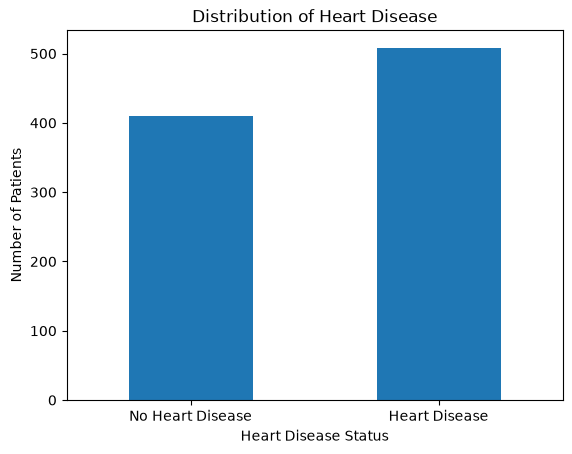

In [28]:
counts = df_clean["HeartDisease"].value_counts().sort_index()

counts.plot(kind="bar")

plt.title("Distribution of Heart Disease")
plt.xlabel("Heart Disease Status")
plt.ylabel("Number of Patients")
plt.xticks([0, 1], ["No Heart Disease", "Heart Disease"], rotation=0)
plt.show()

### Target Variable Distribution

The target variable is relatively balanced, with 508 patients diagnosed with heart disease and 410 patients without heart disease.

This corresponds to approximately 55.3% positive cases and 44.7% negative cases. Therefore, no strong class-balancing technique is required at this stage.

In [29]:
df_clean.groupby("HeartDisease")["Age"].describe()

,count,mean,std,min,25%,50%,75%,max
HeartDisease,,,,,,,,
0,410.0,50.551220,9.444915,28.0,43.0,51.0,57.0,76.0
1,508.0,55.899606,8.727056,31.0,51.0,57.0,62.0,77.0


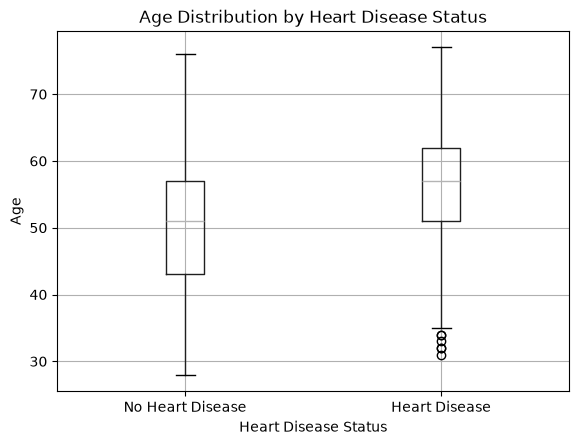

In [30]:
df_clean.boxplot(column="Age", by="HeartDisease")

plt.title("Age Distribution by Heart Disease Status")
plt.suptitle("")
plt.xlabel("Heart Disease Status")
plt.ylabel("Age")
plt.xticks([1, 2], ["No Heart Disease", "Heart Disease"])
plt.show()

### Age and Heart Disease

Patients diagnosed with heart disease tend to be older than patients without heart disease.

The median age is visibly higher in the heart disease group, suggesting that age may be an important predictive feature. However, the age distributions of the two groups overlap considerably, indicating that age alone is not sufficient for classification.

A small number of younger patients appear as statistical outliers in the heart disease group, but these observations are retained because they remain plausible patient records.

In [31]:
pd.crosstab(
    df_clean["Sex"],
    df_clean["HeartDisease"]
)

HeartDisease,0,1
Sex,,
F,143,50
M,267,458


In [32]:
pd.crosstab(
    df_clean["Sex"],
    df_clean["HeartDisease"],
    normalize="index"
) * 100

HeartDisease,0,1
Sex,,
F,74.093264,25.906736
M,36.827586,63.172414


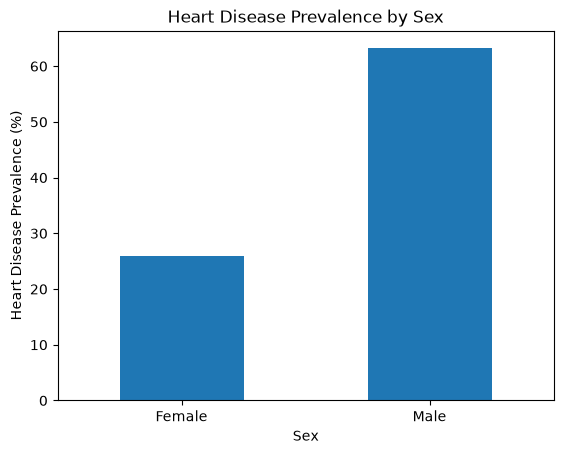

In [33]:
sex_rate = (
    df_clean.groupby("Sex")["HeartDisease"]
    .mean()
    .mul(100)
)

sex_rate.plot(kind="bar")

plt.title("Heart Disease Prevalence by Sex")
plt.xlabel("Sex")
plt.ylabel("Heart Disease Prevalence (%)")
plt.xticks([0, 1], ["Female", "Male"], rotation=0)
plt.show()

### Sex and Heart Disease

Heart disease prevalence differs considerably between male and female patients in this dataset.

Approximately 63.2% of male patients are diagnosed with heart disease, compared with approximately 25.9% of female patients.

This suggests that sex may be an informative predictive feature for the classification models.

However, the dataset contains substantially more male patients than female patients, so this relationship should be interpreted within the context of the sample rather than as a population-level estimate.

In [34]:
pd.crosstab(
    df_clean["ChestPainType"],
    df_clean["HeartDisease"],
    normalize="index"
) * 100

HeartDisease,0,1
ChestPainType,,
ASY,20.967742,79.032258
ATA,86.127168,13.872832
NAP,64.532020,35.467980
TA,56.521739,43.478261


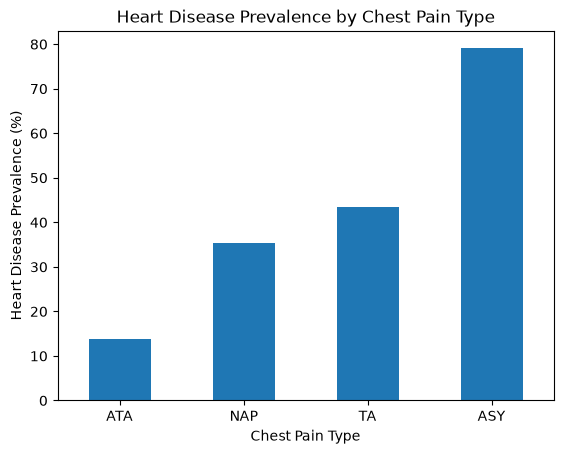

In [35]:
chestpain_rate = (
    df_clean.groupby("ChestPainType")["HeartDisease"]
    .mean()
    .mul(100)
    .sort_values()
)

chestpain_rate.plot(kind="bar")

plt.title("Heart Disease Prevalence by Chest Pain Type")
plt.xlabel("Chest Pain Type")
plt.ylabel("Heart Disease Prevalence (%)")
plt.xticks(rotation=0)
plt.show()

### Chest Pain Type and Heart Disease

Heart disease prevalence varies substantially across chest pain categories.

The asymptomatic (ASY) group shows the highest prevalence of heart disease, at approximately 79.0%. In comparison, prevalence is approximately 43.5% for typical angina (TA), 35.5% for non-anginal pain (NAP), and 13.9% for atypical angina (ATA).

This suggests that chest pain type may be an important predictive feature for the classification models.

However, the number of observations differs between categories, particularly for the TA group, which contains relatively few patients. Therefore, these percentages should be interpreted together with the category sample sizes.

In [36]:
pd.crosstab(
    df_clean["ExerciseAngina"],
    df_clean["HeartDisease"],
    normalize="index"
) * 100

HeartDisease,0,1
ExerciseAngina,,
N,64.899452,35.100548
Y,14.824798,85.175202


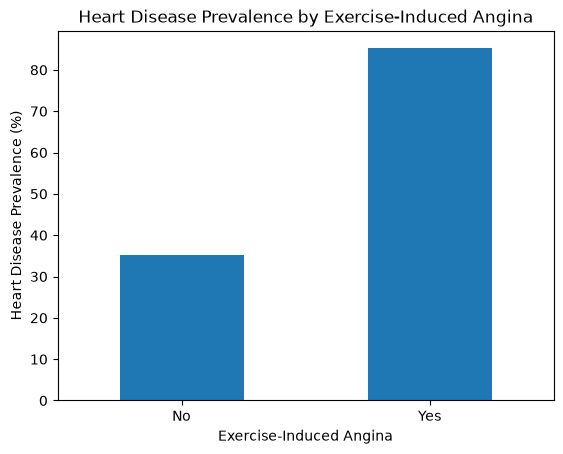

In [37]:
exercise_rate = (
    df_clean.groupby("ExerciseAngina")["HeartDisease"]
    .mean()
    .mul(100)
)

exercise_rate.plot(kind="bar")

plt.title("Heart Disease Prevalence by Exercise-Induced Angina")
plt.xlabel("Exercise-Induced Angina")
plt.ylabel("Heart Disease Prevalence (%)")
plt.xticks([0, 1], ["No", "Yes"], rotation=0)
plt.show()

### Exercise-Induced Angina and Heart Disease

Heart disease prevalence differs substantially according to the presence of exercise-induced angina.

Approximately 85.2% of patients with exercise-induced angina are diagnosed with heart disease, compared with approximately 35.1% of patients without exercise-induced angina.

This strong difference suggests that ExerciseAngina may be an important predictive feature for the machine-learning models.

However, this is an association observed in the dataset and should not be interpreted as evidence that exercise-induced angina directly causes heart disease.

In [38]:
pd.crosstab(
    df_clean["ST_Slope"],
    df_clean["HeartDisease"],
    normalize="index"
) * 100

HeartDisease,0,1
ST_Slope,,
Down,22.222222,77.777778
Flat,17.173913,82.826087
Up,80.253165,19.746835


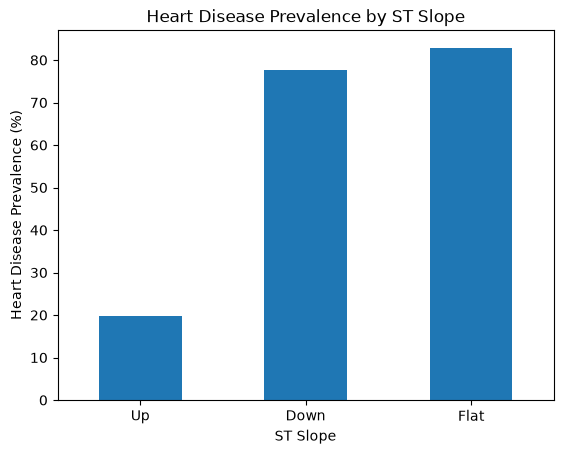

In [39]:
st_slope_rate = (
    df_clean.groupby("ST_Slope")["HeartDisease"]
    .mean()
    .mul(100)
    .sort_values()
)

st_slope_rate.plot(kind="bar")

plt.title("Heart Disease Prevalence by ST Slope")
plt.xlabel("ST Slope")
plt.ylabel("Heart Disease Prevalence (%)")
plt.xticks(rotation=0)
plt.show()

### ST Slope and Heart Disease

Heart disease prevalence differs strongly across ST slope categories.

Approximately 82.8% of patients with a Flat ST slope and 77.8% of patients with a Down ST slope are diagnosed with heart disease, compared with only about 19.7% of patients with an Up ST slope.

This indicates that ST_Slope may be a highly informative predictive feature in this dataset.

However, the Down category contains relatively few observations compared with the Flat and Up categories, so its prevalence estimate should be interpreted with caution.

In [40]:
df_clean.groupby("HeartDisease")["MaxHR"].describe()

,count,mean,std,min,25%,50%,75%,max
HeartDisease,,,,,,,,
0,410.0,148.151220,23.288067,69.0,134.0,150.0,165.00,202.0
1,508.0,127.655512,23.386923,60.0,112.0,126.0,144.25,195.0


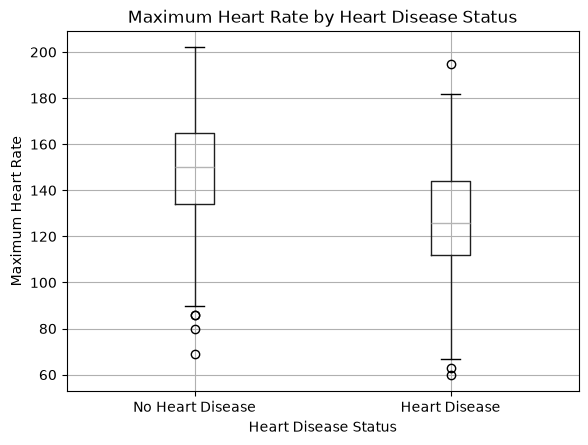

In [41]:
df_clean.boxplot(column="MaxHR", by="HeartDisease")

plt.title("Maximum Heart Rate by Heart Disease Status")
plt.suptitle("")
plt.xlabel("Heart Disease Status")
plt.ylabel("Maximum Heart Rate")
plt.xticks([1, 2], ["No Heart Disease", "Heart Disease"])
plt.show()

### Maximum Heart Rate and Heart Disease

Maximum heart rate differs noticeably between patients with and without heart disease.

Patients without heart disease have a mean maximum heart rate of approximately 148.2 bpm and a median of 150 bpm. In contrast, patients with heart disease have a mean maximum heart rate of approximately 127.7 bpm and a median of 126 bpm.

This suggests that lower maximum heart rate is associated with heart disease status in this dataset and that MaxHR may provide useful predictive information.

Although several statistical outliers are visible, these observations are retained because their values remain plausible and there is no evidence that they represent data-entry errors.

In [42]:
df_clean.groupby("HeartDisease")["Oldpeak"].describe()

,count,mean,std,min,25%,50%,75%,max
HeartDisease,,,,,,,,
0,410.0,0.408049,0.699709,-1.1,0.0,0.0,0.6,4.2
1,508.0,1.274213,1.151872,-2.6,0.0,1.2,2.0,6.2


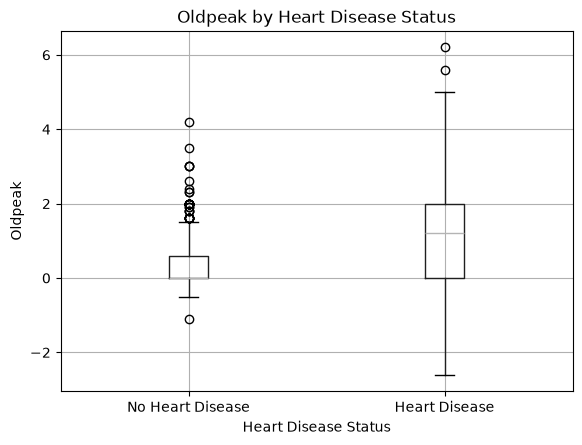

In [43]:
df_clean.boxplot(column="Oldpeak", by="HeartDisease")

plt.title("Oldpeak by Heart Disease Status")
plt.suptitle("")
plt.xlabel("Heart Disease Status")
plt.ylabel("Oldpeak")
plt.xticks([1, 2], ["No Heart Disease", "Heart Disease"])
plt.show()

### Oldpeak and Heart Disease

Oldpeak values differ noticeably between patients with and without heart disease.

Patients without heart disease have a mean Oldpeak of approximately 0.41 and a median of 0.0. In contrast, patients with heart disease have a mean Oldpeak of approximately 1.27 and a median of 1.2.

This suggests that higher exercise-induced ST depression is associated with heart disease status in this dataset and that Oldpeak may provide useful predictive information.

Several statistical outliers are present in both groups. These observations are retained because there is no clear evidence that they represent data-entry errors.

In [44]:
pd.crosstab(
    df_clean["FastingBS"],
    df_clean["HeartDisease"],
    normalize="index"
) * 100

HeartDisease,0,1
FastingBS,,
0,51.988636,48.011364
1,20.560748,79.439252


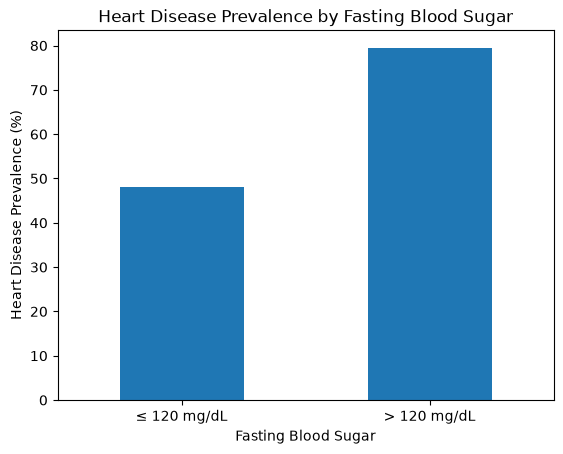

In [45]:
fasting_rate = (
    df_clean.groupby("FastingBS")["HeartDisease"]
    .mean()
    .mul(100)
)

fasting_rate.plot(kind="bar")

plt.title("Heart Disease Prevalence by Fasting Blood Sugar")
plt.xlabel("Fasting Blood Sugar")
plt.ylabel("Heart Disease Prevalence (%)")
plt.xticks(
    [0, 1],
    ["≤ 120 mg/dL", "> 120 mg/dL"],
    rotation=0
)
plt.show()

### Fasting Blood Sugar and Heart Disease

Heart disease prevalence differs according to fasting blood sugar status.

Approximately 79.4% of patients with fasting blood sugar above 120 mg/dL are diagnosed with heart disease, compared with approximately 48.0% of patients with fasting blood sugar at or below 120 mg/dL.

This suggests that FastingBS may provide useful predictive information for the classification models.

However, this relationship represents an association observed in the dataset and should not be interpreted as a causal effect.

In [46]:
pd.crosstab(
    df_clean["RestingECG"],
    df_clean["HeartDisease"],
    normalize="index"
) * 100

HeartDisease,0,1
RestingECG,,
LVH,43.617021,56.382979
Normal,48.369565,51.630435
ST,34.269663,65.730337


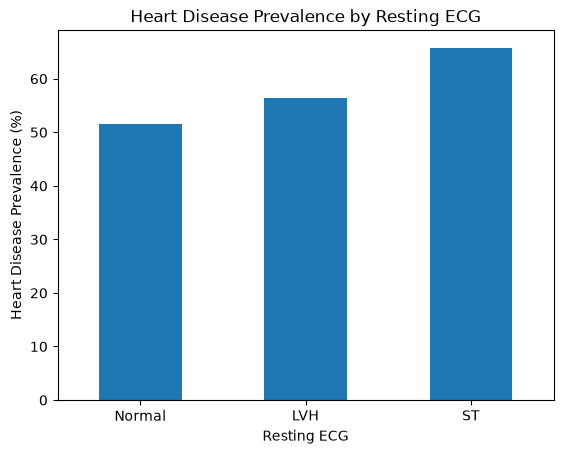

In [47]:
ecg_rate = (
    df_clean.groupby("RestingECG")["HeartDisease"]
    .mean()
    .mul(100)
    .sort_values()
)

ecg_rate.plot(kind="bar")

plt.title("Heart Disease Prevalence by Resting ECG")
plt.xlabel("Resting ECG")
plt.ylabel("Heart Disease Prevalence (%)")
plt.xticks(rotation=0)
plt.show()

### Resting ECG and Heart Disease

Heart disease prevalence varies moderately across resting ECG categories.

Approximately 51.6% of patients with a Normal resting ECG are diagnosed with heart disease, compared with approximately 56.4% for the LVH category and 65.7% for the ST category.

The differences between categories are smaller than those observed for features such as ST_Slope, ExerciseAngina, or ChestPainType. Therefore, RestingECG may provide useful predictive information, but its individual association with heart disease appears relatively moderate in this dataset.

In [48]:
df_clean.groupby("HeartDisease")["RestingBP"].describe()

,count,mean,std,min,25%,50%,75%,max
HeartDisease,,,,,,,,
0,410.0,130.180488,16.499585,80.0,120.0,130.0,140.0,190.0
1,507.0,134.449704,18.928797,92.0,120.0,132.0,145.0,200.0


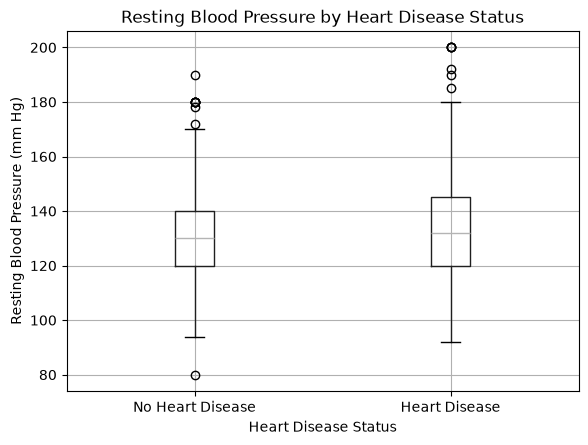

In [49]:
df_clean.boxplot(column="RestingBP", by="HeartDisease")

plt.title("Resting Blood Pressure by Heart Disease Status")
plt.suptitle("")
plt.xlabel("Heart Disease Status")
plt.ylabel("Resting Blood Pressure (mm Hg)")
plt.xticks([1, 2], ["No Heart Disease", "Heart Disease"])
plt.show()

### Resting Blood Pressure and Heart Disease

Resting blood pressure shows only a modest difference between patients with and without heart disease.

Patients without heart disease have a mean resting blood pressure of approximately 130.2 mm Hg and a median of 130 mm Hg. Patients with heart disease have a mean of approximately 134.4 mm Hg and a median of 132 mm Hg.

The distributions overlap substantially, suggesting that RestingBP may have limited predictive power when considered independently.

Several statistical outliers are present, but they are retained because there is no clear evidence that they represent invalid measurements.

In [50]:
df_clean.groupby("HeartDisease")["Cholesterol"].apply(
    lambda x: x.isnull().sum()
)

HeartDisease
0     20
1    152
Name: Cholesterol, dtype: int64

In [51]:
df_clean.groupby("HeartDisease")["Cholesterol"].apply(
    lambda x: x.isnull().mean() * 100
)

HeartDisease
0     4.878049
1    29.921260
Name: Cholesterol, dtype: float64

In [52]:
df_clean.groupby("HeartDisease")["Cholesterol"].describe()

,count,mean,std,min,25%,50%,75%,max
HeartDisease,,,,,,,,
0,390.0,238.769231,55.394617,85.0,203.0,231.5,269.00,564.0
1,356.0,251.061798,62.462713,100.0,212.0,246.0,283.25,603.0


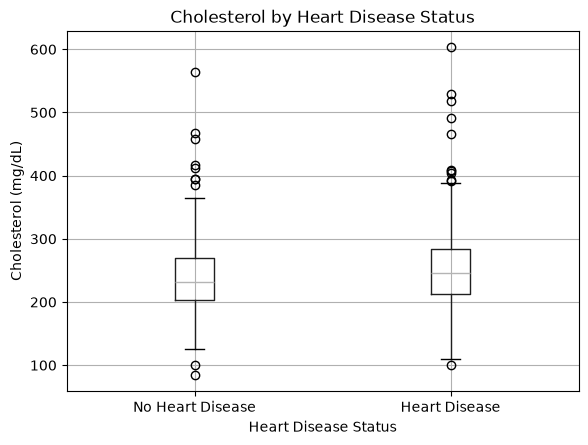

In [53]:
df_clean.boxplot(column="Cholesterol", by="HeartDisease")

plt.title("Cholesterol by Heart Disease Status")
plt.suptitle("")
plt.xlabel("Heart Disease Status")
plt.ylabel("Cholesterol (mg/dL)")
plt.xticks([1, 2], ["No Heart Disease", "Heart Disease"])
plt.show()

### Cholesterol and Heart Disease

Among patients with available cholesterol measurements, cholesterol levels are moderately higher in the heart disease group.

Patients without heart disease have a mean cholesterol level of approximately 238.8 mg/dL and a median of 231.5 mg/dL, whereas patients with heart disease have a mean of approximately 251.1 mg/dL and a median of 246 mg/dL.

However, the distributions overlap substantially, suggesting that cholesterol alone may provide limited discriminatory information.

An important data-quality issue is the unequal distribution of missing cholesterol measurements. Approximately 4.9% of patients without heart disease have unavailable cholesterol measurements, compared with approximately 29.9% of patients with heart disease.

Because missing cholesterol values are strongly associated with the target variable, they will require careful treatment during preprocessing. Rows with missing cholesterol will not be removed, since this would disproportionately exclude patients from the heart disease class. Sensitivity analyses will be considered to evaluate the effect of cholesterol imputation and missingness on model performance.

## EDA Summary

The exploratory analysis identified several variables with clear associations with heart disease status.

The strongest differences were observed for ST_Slope, ExerciseAngina, and ChestPainType. MaxHR, Sex, Age, Oldpeak, and FastingBS also showed noticeable differences between patients with and without heart disease.

RestingECG and RestingBP showed comparatively weaker differences when considered independently.

Cholesterol requires special attention because 172 zero values were interpreted as unavailable measurements. Missing cholesterol measurements were substantially more common among patients with heart disease than among patients without heart disease. Therefore, missing cholesterol values will be handled within the preprocessing pipeline rather than by removing affected observations.

These exploratory findings describe associations in the dataset and do not establish causal relationships. All features will initially be retained for machine-learning experiments because multivariate models may identify relationships that are not visible through individual feature analysis.